Гипотеза 2: удаление коррелируемых признаков.

Предпалагается, что произойдет уменьшение мультиколлинеарности и избыточности в данных путем удаления признаков с высокой корреляцией, что потенциально может улучшить качество модели и ускорить обучение.

In [9]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')
print(f"Размер тренировочных данных: {df_train.shape}")
print(f"Размер тестовых данных: {df_test.shape}")

Размер тренировочных данных: (307511, 571)
Размер тестовых данных: (48744, 570)


In [3]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [4]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

In [5]:
common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [6]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [7]:
for col in X_train_full.columns:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')

for col in X_train_full.columns:
    if X_train_full[col].dtype in ['float64', 'int64']:
        X_train_full[col].fillna(X_train_full[col].median(), inplace=True)
        df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1661528756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19132\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documenta

In [ ]:
numeric_cols = X_train_full.select_dtypes(include=['float64', 'int64']).columns.tolist()
exclude_cols = ['sk_id_curr', 'target', 'sk_id_bureau', 'sk_id_prev']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

if len(numeric_cols) > 150:
    variances = X_train_full[numeric_cols].var().sort_values(ascending=False)
    numeric_cols = variances.head(150).index.tolist()

corr_matrix = X_train_full[numeric_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for column in upper.columns:
    high_corr = upper[column][upper[column] > 0.8]
    if not high_corr.empty:
        for corr_col, corr_value in high_corr.items():
            var_current = X_train_full[column].var()
            var_correlated = X_train_full[corr_col].var()
            
            if var_current <= var_correlated and column not in to_drop:
                to_drop.append(column)

X_train_reduced = X_train_full.drop(to_drop, axis=1)
df_test_reduced = df_test_processed.drop(to_drop, axis=1)

print(f"Размер train до: {X_train_full.shape}, после: {X_train_reduced.shape}")
print(f"Размер test до: {df_test_processed.shape}, после: {df_test_reduced.shape}")

if 'cat_cols' in locals():
    cat_cols = [col for col in cat_cols if col not in to_drop]

X_train_full = X_train_reduced
df_test_processed = df_test_reduced


Размер train до: (307511, 504), после: (307511, 455)
Размер test до: (48744, 504), после: (48744, 455)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [12]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.7060620	best: 0.7060620 (0)	total: 1.45s	remaining: 24m 9s
100:	test: 0.7617218	best: 0.7617218 (100)	total: 1m 41s	remaining: 15m 2s
200:	test: 0.7716118	best: 0.7716118 (200)	total: 3m 18s	remaining: 13m 9s
300:	test: 0.7760742	best: 0.7760742 (300)	total: 4m 56s	remaining: 11m 27s
400:	test: 0.7788506	best: 0.7788506 (400)	total: 6m 33s	remaining: 9m 47s
500:	test: 0.7815528	best: 0.7815528 (500)	total: 8m 12s	remaining: 8m 10s
600:	test: 0.7830138	best: 0.7830138 (600)	total: 9m 53s	remaining: 6m 33s
700:	test: 0.7839567	best: 0.7839567 (700)	total: 11m 33s	remaining: 4m 55s
800:	test: 0.7846389	best: 0.7846389 (800)	total: 13m 14s	remaining: 3m 17s
900:	test: 0.7852628	best: 0.7852628 (900)	total: 14m 56s	remaining: 1m 38s
999:	test: 0.7858323	best: 0.7858492 (992)	total: 16m 39s	remaining: 0us

bestTest = 0.7858492165
bestIteration = 992

Shrink model to first 993 iterations.


In [15]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7858
Validation Accuracy: 0.9035
Validation Precision: 0.3605
Validation Recall: 0.2524
Validation F1-Score: 0.2969


In [16]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_2.csv', index=False)

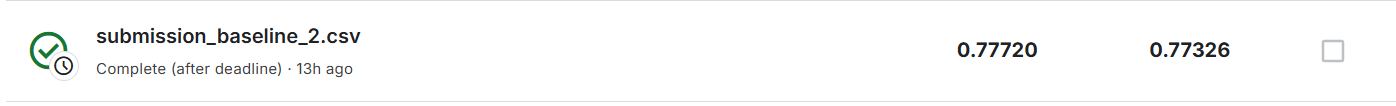

Видим, что улучшение качества модели не произошло. Гипотеза не сработала